# GPU Metrics Data Processing & Imputation Notebook

This notebook performs end-to-end processing of GPU utilization metrics from Nessie/Iceberg tables using Spark on Enterprise Gateway (SparkCaster). It includes feature engineering, ML-based imputation of missing `redfish_power` values, and writes the results back to Nessie.

---

## 📋 Notebook Structure

### **Setup & Initialization** (Cells 1-5)

- **Cell 1**: Package installation - Installs required Python packages including PySpark, Nessie/Iceberg connectors, visualization libraries, and ML tools
- **Cell 2**: Credential management - Sets up encrypted keyring for secure storage of Nessie credentials
- **Cell 3**: Credential validation - Verifies Nessie connection and authentication
- **Cell 4**: Spark cluster setup - Configures SparkCaster session with Nessie/Iceberg catalog, cleans up existing sessions, and initializes Spark context
- **Cell 5**: Data loading - Queries source data from Nessie using Spark SQL

### **Feature Engineering** (Cells 6-7)

- **Cell 6**: Feature engineering pipeline - Creates derived features for modeling and analysis:
  - `tensor_to_gpu_ratio` - Tensor utilization relative to GPU utilization
  - `memory_intensity` - Memory copy utilization relative to GPU utilization
  - `compute_to_memory_ratio` - Compute throughput relative to memory usage
  - `power_%_max` - Power usage as percentage of maximum
  - `compute_%_max` - Compute usage as percentage of maximum
  - `gen` - GPU generation classification (current_gen vs prior_gen)
  - `training_inference` - Simple workload classification:
    - **active_training**: `is_training == "slurm"`
    - **non_training**: `is_training != "slurm"`
    
- **Cell 7**: DataFrame creation - Prepares final DataFrame with all features for modeling

### **ML Model Training & Evaluation** (Cells 8-12)

- **Cell 8**: Complete ML pipeline with 5-fold cross-validation - Trains and evaluates multiple regression models to predict `redfish_power`:
  - Model 1: Simple linear regression (`chip_power` only)
  - Model 2: Multiple features (`chip_power`, `gpu_util`, `tensor_util`, `tensor_tflops`)
  - Uses cross-validation to select best model
  - Caches training data for performance
  
- **Cell 9**: Model 1 training - Simple linear regression baseline using only `chip_power`
- **Cell 10**: Memory cleanup - Unpersists cached data to free memory
- **Cell 11**: Diagnostic plots - Generates QQ plots and predicted vs actual visualizations for all trained models
- **Cell 12**: Final model training - Retrains the best performing model on optimized sample size (10% of data) for production use

### **Data Imputation** (Cells 13-14)

- **Cell 13**: Imputation execution - Applies the trained model to predict missing `redfish_power` values across the full dataset
  - Identifies rows with missing values
  - Applies ML model predictions
  - Creates `redfish_power_imputed` flag for tracking
  - Combines imputed and original data
  - Reports imputation statistics
  
- **Cell 14**: Schema verification - Prints final DataFrame schema after imputation

### **Analysis & Visualization** (Cells 15-16)

- **Cell 15**: Classification analysis - Analyzes the `training_inference` feature distribution and relationships with power metrics
- **Cell 16**: Classification visualization - Creates plots showing training vs inference workload patterns

### **Data Output to Nessie** (Cells 17-20)

- **Cell 17**: Write to Nessie - Writes the complete imputed dataset to Nessie/Iceberg table
  - **Target table**: `sandbox.sandbox_finance.dcgm_metrics_raw_impute`
  - Includes all original columns plus engineered features
  - Uses Iceberg table format for time-travel and ACID properties
  - Reports write statistics (row count, duration, throughput)
  
- **Cell 18-20**: Data validation and testing - Verification queries to confirm successful write and data quality

---

## 🎯 Key Features

- **Feature Engineering**: Creates 7 derived features including GPU generation, workload classification, and performance ratios
- **Simplified Classification**: Binary workload classification (active_training vs non_training) based on Slurm job detection
- **ML-based Imputation**: Uses Spark MLlib with cross-validation to select best regression model for missing power values
- **Scalable Processing**: Designed for large datasets using Spark 3.5.5 on Enterprise Gateway (SparkCaster)
- **Nessie/Iceberg Output**: Writes to Iceberg tables for versioning, time-travel, and ACID guarantees
- **Secure Credentials**: Encrypted keyring storage for database passwords
- **Data Validation**: Built-in schema verification and row count checks

---

## 🚀 Quick Start

1. **Setup** (Cells 1-4): Install packages, configure credentials, initialize SparkCaster
2. **Load Data** (Cell 5): Query source data from Nessie
3. **Feature Engineering** (Cells 6-7): Create derived features including simplified training/inference classification
4. **Train Models** (Cells 8-12): Train ML models with cross-validation, select best model
5. **Impute** (Cells 13-14): Apply model to predict missing `redfish_power` values
6. **Analyze** (Cells 15-16): Explore workload classification patterns
7. **Write Output** (Cell 17): Save imputed dataset to Nessie/Iceberg table
8. **Validate** (Cells 18-20): Verify data quality and row counts

---

## 📊 Key Data Assets

### Input Data
- **Source**: Nessie/Iceberg table via Spark SQL
- **Catalog**: `sandbox.sandbox_finance`
- **Processing**: In-memory Spark DataFrames with distributed processing

### Output Data
- **Target Table**: `sandbox.sandbox_finance.dcgm_metrics_raw_impute`
- **Format**: Apache Iceberg (enables time-travel, schema evolution, ACID transactions)
- **Features**: 21+ columns including:
  - Original metrics: `datestamp`, `node`, `gpu_util`, `tensor_util`, `chip_power`, `redfish_power`
  - Engineered features: `tensor_to_gpu_ratio`, `memory_intensity`, `compute_to_memory_ratio`, `power_%_max`, `compute_%_max`, `gen`, `training_inference`
  - Imputation metadata: `redfish_power_imputed` flag

### ML Features for Imputation
Primary model predictors (selected via cross-validation):
- `chip_power` - GPU chip power consumption (primary predictor)
- `gpu_util` - GPU utilization percentage
- `tensor_util` - Tensor core utilization
- `tensor_tflops` - Tensor FLOPS performance

### Workload Classification Logic
Simple binary classification for `training_inference` feature:
- **active_training**: Records where `is_training == "slurm"` (GPU actively running Slurm training jobs)
- **non_training**: All other records (`is_training != "slurm"`)

---

## 🔧 Technical Configuration

### SparkCaster / Enterprise Gateway
- **Spark Version**: 3.5.5
- **Catalog**: Nessie with Iceberg tables
- **Processing**: Distributed Spark DataFrames
- **Caching**: Strategic caching for model training performance

### ML Configuration
- **Framework**: Spark MLlib
- **Validation**: 5-fold cross-validation
- **Models Tested**: Simple and multi-feature linear regression
- **Training Sample**: 10% of data (optimized for performance vs accuracy)
- **Evaluation Metrics**: RMSE, R², MAE

### Data Output
- **Format**: Apache Iceberg (via Nessie catalog)
- **Write Mode**: Append/Overwrite (configurable)
- **Validation**: Row count verification after write
- **Benefits**: Time-travel, schema evolution, ACID properties, efficient updates

---

## ⚠️ Important Notes

- Feature engineering creates the simplified `training_inference` binary classification (active_training / non_training)
- The notebook uses cross-validation to automatically select the best performing ML model
- All imputed `redfish_power` values are flagged with `redfish_power_imputed` for traceability
- Nessie/Iceberg provides versioning - you can query previous versions of the table using time-travel
- Strategic data caching is used during model training to improve performance
- The complete pipeline is designed to run end-to-end without manual intervention

In [1]:
#install needed packages

import importlib
import subprocess
import sys

def is_module_available(module_name: str) -> bool:
    """Return True if the importable module exists; handles dotted names safely."""
    try:
        return importlib.util.find_spec(module_name) is not None
    except ModuleNotFoundError:
        return False

def install_if_missing(pip_name: str, import_name: str = None):
    """
    Install `pip_name` only if `import_name` (or `pip_name` if None) is not importable.
    Use this to handle cases where pip/distribution names differ from import names.
    """
    import_name = import_name or pip_name
    if not is_module_available(import_name):
        print(f"Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
    else:
        print(f"{pip_name} already installed.")

# --- Packages for Nessie/Iceberg access ---
# simple 1:1 cases
install_if_missing("keyring", "keyring")
install_if_missing("ipython-secrets", "ipython_secrets")
install_if_missing("pyarrow", "pyarrow")
install_if_missing("fsspec", "fsspec")
install_if_missing("s3fs", "s3fs")
install_if_missing("statsmodels", "statsmodels")
install_if_missing("matplotlib", "matplotlib")
install_if_missing("scikit-learn", "sklearn")
install_if_missing("xgboost", "xgboost")

# special cases
# keyrings.cryptfile installs a plugin under the 'keyrings' package; checking the root avoids ModuleNotFoundError
install_if_missing("keyrings.cryptfile", "keyrings")

# Core viz + scaling pins for Python 3.11.11
install_if_missing("bokeh==3.6.2", "bokeh")
install_if_missing("jupyter_bokeh", "jupyter_bokeh")
install_if_missing("panel==1.5.2", "panel")
install_if_missing("holoviews==1.19.0", "holoviews")
install_if_missing("hvplot==0.10.0", "hvplot")
install_if_missing("datashader==0.16.3", "datashader")
install_if_missing("dask[dataframe]==2024.9.1", "dask")
install_if_missing("distributed==2024.9.1", "distributed")
install_if_missing("reportlab", "reportlab")


print("\n✓ All packages installed/verified")




keyring already installed.
ipython-secrets already installed.
pyarrow already installed.
fsspec already installed.
s3fs already installed.
Installing statsmodels ...
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 83.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]
Installing matplotlib ...
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 89.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 172.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 46.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━ 4/5 [matplotlib]

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [matplotlib]5 [matplotlib]
scikit-learn already installed.
Installing xgboost ...
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 276.8 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 262.0 MB/s  0:00:010:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]
keyrings.cryptfile already installed.
Installing bokeh==3.6.2 ...
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 64.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [bokeh]32m1/2 [bokeh]
Installing jupyter_bokeh ...


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Defaulting to user installation because normal site-packages is not writeable
Installing panel==1.5.2 ...
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.4/27.4 MB 77.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━ 5/6 [panel]

...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [datashader]
Installing dask[dataframe]==2024.9.1 ...
Defaulting to user installation because normal site-packages is not writeable
INFO: pip is looking at multiple versions of dask-expr to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 145.6 MB/s  0:00:00
  Attempting uninstall: dask
    Found existing installation: dask 2026.3.0
    Uninstalling dask-2026.3.0:
      Successfully uninstalled dask-2026.3.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0/2 [dask]

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [dask-expr]
Installing distributed==2024.9.1 ...
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 36.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━ 2/3 [distributed]

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [distributed]
Installing reportlab ...
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 62.4 MB/s  0:00:00

✓ All packages installed/verified


In [2]:
#set up caios credentials
import keyring
import os
from getpass import getpass
from keyrings.cryptfile.cryptfile import CryptFileKeyring
from pathlib import Path

# Use home directory dynamically instead of hardcoded path
home_dir = str(Path.home())
os.environ["KEYRING_CRYPTFILE_PATH"] = f"{home_dir}/.local/share/python_keyring/cryptfile_pass.cfg"

kr = CryptFileKeyring()
kr.keyring_key = getpass("Set/enter master password for encrypted keyring: ")
keyring.set_keyring(kr)

# Prompt for CAIOS credentials if not already stored
caios_access_key = keyring.get_password("caios", "access_key")
caios_secret_key = keyring.get_password("caios", "secret_key")  

if not caios_access_key:
    caios_access_key = input("Enter CAIOS access key: ")
    keyring.set_password("caios", "access_key", caios_access_key)

if not caios_secret_key:
    caios_secret_key = getpass("Enter CAIOS secret key: ")
    keyring.set_password("caios", "secret_key", caios_secret_key)

print("✓ CAIOS credentials configured")

✓ CAIOS credentials configured


In [3]:
#credential validation
import keyring

# Retrieve CAIOS credentials from keyring
caios_access_key = keyring.get_password("caios", "access_key")
caios_secret_key = keyring.get_password("caios", "secret_key")

assert caios_access_key and caios_secret_key, "No CAIOS credentials in keyring."

print("✓ CAIOS credentials validated")
print(f"  Access key: {caios_access_key[:8]}...{caios_access_key[-4:]}")

✓ CAIOS credentials validated
  Access key: CWOXOUIF...MSKY


In [4]:
# CLEAN UP EXISTING SESSION
# ========================================
from spark.nessie.client import NessieSparkClient


try:
    existing_spark = SparkSession.getActiveSession()
    if existing_spark:
        print("Stopping existing Spark session...")
        existing_spark.stop()
        print("✓ Existing Spark session stopped")
    else:
        print("No existing Spark session found")
except Exception as e:
    print(f"Note: Could not check for existing session: {e}")

ness = NessieSparkClient(
    svc_url="http://kf-proxy.nessie.svc.cluster.local:19120/api/v2",
    nessie_endpoint="http://nessie-prd.cwobject.com",
    caios_access_key=caios_access_key,
    caios_secret_key=caios_secret_key,
    dbtcaster=True,
)

spark = ness.spark

spark.sparkContext.setLogLevel("ERROR")

# ========================================
# SESSION DIAGNOSTICS
# ========================================
print("=" * 60)
print("SPARK CLUSTER CONFIGURATION - NESSIE SPARK CLIENT")
print("=" * 60)
print(f"Spark Version: {spark.version}")
print(f"Spark Master: {spark.sparkContext.master}")
print(f"App Name: {spark.sparkContext.appName}")
print(f"Application ID: {spark.sparkContext.applicationId}")
print("Nessie Service URL: http://kf-proxy.nessie.svc.cluster.local:19120/api/v2")
print("Nessie Endpoint: http://nessie-prd.cwobject.com")
print("DBTCaster Mode: Enabled")
print("AWS Environment Variables: Set (AWS_ACCESS_KEY_ID, AWS_SECRET_ACCESS_KEY)")

for k in [
    "spark.driver.memory",
    "spark.driver.cores",
    "spark.executor.instances",
    "spark.executor.cores",
    "spark.executor.memory",
    "spark.sql.shuffle.partitions",
    "spark.sql.adaptive.enabled",
]:
    try:
        print(f"{k}: {spark.conf.get(k)}")
    except Exception:
        print(f"{k}: <unset>")

try:
    executor_count = spark.sparkContext._jsc.sc().getExecutorMemoryStatus().size()
    print(f"Executor entries visible: {executor_count}")
except Exception as e:
    print(f"Could not inspect executor status: {e}")

print("=" * 60)



Note: Could not check for existing session: name 'SparkSession' is not defined
SPARK CLUSTER CONFIGURATION - NESSIE SPARK CLIENT
Spark Version: 3.5.5
Spark Master: k8s://https://10.16.0.1:443
App Name: sparkcaster-jbok-10784d62-cdb0-45cf-86b2-b88a42fb4ff8
Application ID: spark-563b9404c0f948bda5a9d168f7d9cb59
Nessie Service URL: http://kf-proxy.nessie.svc.cluster.local:19120/api/v2
Nessie Endpoint: http://nessie-prd.cwobject.com
DBTCaster Mode: Enabled
AWS Environment Variables: Set (AWS_ACCESS_KEY_ID, AWS_SECRET_ACCESS_KEY)
spark.driver.memory: 16g
spark.driver.cores: 4
spark.executor.instances: 10
spark.executor.cores: 4
spark.executor.memory: 64g
spark.sql.shuffle.partitions: 200
spark.sql.adaptive.enabled: true
Executor entries visible: 9


In [6]:
#query data
df_imputed = ness.sql("select * from sandbox.sandbox_finance.dcgm_metrics_raw_impute")
df_imputed.show(5, truncate=False)
df_imputed.printSchema()

+-------------------+-------+--------+--------------------+------------------+-------------------+-------------+----------+-------------------+--------+--------------------+------+-----+-------+-----------+------+---------------------+------+------------------+-------------+-----------------+---------------------+-------+----------------+----------------+-----------+------------+------------------+----------------+---------------+---------------+----------------------+--------------------------+-----------------------+----------------------+-----------------+-----------------+-------------------------+---------------------+-------------------+-----------------------+-------------------+--------------------+---------+------------------+
|datestamp          |node   |gpu_util|tensor_util         |chip_power        |dram_active        |mem_copy_util|vram_usage|sm_active          |sm_clock|sm_occupancy        |region|zone |cluster|cluster_org|cw_sku|model                |serial|redfish_powe

In [8]:
# ========================================
# [4/9] Learning Curve (GBT)
# ========================================
print("[4/9] Learning curve with GBTClassifier...")

lc_fracs = []
frac = LC_START
while frac <= LC_END + 1e-9:
    lc_fracs.append(round(frac, 6))
    frac += LC_STEP

lc_results = []

# Evaluators
lc_evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="accuracy"
)
lc_evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1"
)

# Precompute encoded + assembled features once (GBT does not need scaling)
print("Preparing full feature matrix (one-time transform)...")
df_encoded_full = encoding_model.transform(df_classification)
df_features_full = assembler.transform(df_encoded_full)
df_ml_full = df_features_full.select("features_raw", "label", TARGET_COL).cache()
_ = df_ml_full.count()

for frac in lc_fracs:
    print(f"→ Sample size: {frac*100:.2f}%")
    sample_df = stratified_sample(df_ml_full, TARGET_COL, frac, seed=SEED)

    # Split train/test
    train_df, test_df = sample_df.randomSplit([0.8, 0.2], seed=SEED)

    # GBT classifier (use raw features)
    gbt = GBTClassifier(
        featuresCol="features_raw",
        labelCol="label",
        maxIter=20,
        maxDepth=3,
        stepSize=0.1,
        subsamplingRate=0.8,
        seed=SEED
    )

    start = time.time()
    gbt_model = gbt.fit(train_df)
    train_time = time.time() - start

    preds = gbt_model.transform(test_df)
    acc = lc_evaluator_acc.evaluate(preds)
    f1 = lc_evaluator_f1.evaluate(preds)

    lc_results.append((frac, acc, f1, train_time))
    print(f"    Accuracy: {acc:.4f} | F1: {f1:.4f} | Time: {train_time:.1f}s")

lc_results_df = pd.DataFrame(lc_results, columns=["sample_frac", "accuracy", "f1", "train_time_s"])
print("Learning curve results:")
print(lc_results_df.to_string(index=False))


Installing required packages...
✓ Packages installed
CLASSIFICATION ANALYSIS: training_inference
Target variable: training_inference
Learning curve: 0.1% to 5.0% in 0.5% steps
[1/9] Preparing data...
Class distribution in training_inference:
+------------------+---------+
|training_inference|    count|
+------------------+---------+
|      non_training|535680372|
|   active_training|377001028|
+------------------+---------+

Numeric features: 20
Categorical features: 1
✓ Data prepared
[2/9] Preparing stratified sampling...
Classes: ['non_training', 'active_training']
[3/9] Fitting encoding pipeline (on full data)...
✓ Encoded 1 categorical features
[4/9] Learning curve with GBTClassifier...
→ Sample size: 0.10%
    Accuracy: 0.8100 | F1: 0.8107 | Time: 489.9s
→ Sample size: 0.60%
    Accuracy: 0.8098 | F1: 0.8104 | Time: 377.7s
→ Sample size: 1.10%
    Accuracy: 0.8110 | F1: 0.8116 | Time: 795.6s
→ Sample size: 1.60%
    Accuracy: 0.8103 | F1: 0.8108 | Time: 890.7s
→ Sample size: 2.10%

[E 2026-05-22 17:26:03,254.254 root] KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "/opt/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
  File "/opt/spark/python/lib/py4j-0.10.9.7-src.zip/py4j/clientserver.py", line 511, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
  File "/usr/lib/python3.10/socket.py", line 705, in readinto
    return self._sock.recv_into(b)
KeyboardInterrupt


KeyboardInterrupt: 

In [12]:
# ========================================
# [5/9] Final Stratified Sample for Full Training
# ========================================
# Final stratified sample size (set after reviewing learning curve)
FINAL_SAMPLE_FRAC = 0.001  # 1% default; update after learning curve

print("[5/9] Applying final stratified sample...")
print(f"Final sample fraction: {FINAL_SAMPLE_FRAC*100:.2f}%")

from pyspark import StorageLevel

df_sampled = stratified_sample(df_classification, TARGET_COL, FINAL_SAMPLE_FRAC, seed=SEED)
# Cache sampled data once since it's reused in multiple transforms
# MEMORY_AND_DISK avoids recompute if it doesn't all fit in memory
_df_sampled_cached = df_sampled.persist(StorageLevel.MEMORY_AND_DISK)
_ = _df_sampled_cached.count()

# ========================================
# [6/9] Feature Engineering for Classification
# ========================================
print("[6/9] Encoding features...")

# Apply encoding model
_df_encoded = encoding_model.transform(_df_sampled_cached)

# ========================================
# [7/9] Feature Assembly and Scaling
# ========================================
print("[7/9] Assembling and scaling features...")

df_features = assembler.transform(_df_encoded)
scaler_model_final = scaler.fit(df_features)
df_scaled = scaler_model_final.transform(df_features)

# Select only needed columns
# Persist for downstream training to avoid recomputation
_df_ml_cached = df_scaled.select("features", "label", TARGET_COL).persist(StorageLevel.MEMORY_AND_DISK)
_ = _df_ml_cached.count()

df_ml = _df_ml_cached

print(f"✓ Features assembled and scaled")

# Split train/test
train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=SEED)
train_df.persist(StorageLevel.MEMORY_AND_DISK)
test_df.persist(StorageLevel.MEMORY_AND_DISK)

# Materialize once so training doesn't pay the full lineage cost
train_count = train_df.count()
test_count = test_df.count()

print(f"Train: {train_count:,} | Test: {test_count:,}")

# ========================================
# [8/9] Model Training with Spark MLlib
# ========================================
print("[8/9] Training classification models...")

evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="accuracy"
)
evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1"
)

results = []

# Model 1: Logistic Regression (Fast baseline - trains first)
print("  [1/3] Training Logistic Regression...")
lr_start = time.time()
lr = MLLogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=100,
    regParam=0.01
)
lr_model = lr.fit(train_df)
lr_time = time.time() - lr_start

lr_pred = lr_model.transform(test_df)
lr_acc = evaluator_acc.evaluate(lr_pred)
lr_f1 = evaluator_f1.evaluate(lr_pred)

print(f"    Accuracy: {lr_acc:.4f} | F1: {lr_f1:.4f} | Time: {lr_time:.1f}s")
results.append(("Logistic Regression", lr_acc, lr_f1, lr_time))

# Model 2: Random Forest (For feature importance - trains second)
print("  [2/3] Training Random Forest...")
rf_start = time.time()
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=100,
    maxDepth=10,
    seed=SEED
)
rf_model = rf.fit(train_df)
rf_time = time.time() - rf_start

rf_pred = rf_model.transform(test_df)
rf_acc = evaluator_acc.evaluate(rf_pred)
rf_f1 = evaluator_f1.evaluate(rf_pred)

print(f"    Accuracy: {rf_acc:.4f} | F1: {rf_f1:.4f} | Time: {rf_time:.1f}s")
results.append(("Random Forest", rf_acc, rf_f1, rf_time))

# Model 3: GBT Classifier
print("  [3/3] Training GBT Classifier...")
gbt_start = time.time()
gbt = GBTClassifier(
    featuresCol="features",
    labelCol="label",
    maxIter=50,
    maxDepth=5,
    stepSize=0.1,
    subsamplingRate=0.8,
    seed=SEED
)
gbt_model = gbt.fit(train_df)
gbt_time = time.time() - gbt_start

gbt_pred = gbt_model.transform(test_df)
gbt_acc = evaluator_acc.evaluate(gbt_pred)
gbt_f1 = evaluator_f1.evaluate(gbt_pred)

print(f"    Accuracy: {gbt_acc:.4f} | F1: {gbt_f1:.4f} | Time: {gbt_time:.1f}s")
results.append(("GBT Classifier", gbt_acc, gbt_f1, gbt_time))


print("" + "="*60)
print("MODEL COMPARISON")
print("="*60)
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1 Score", "Time (s)"])
print(results_df.to_string(index=False))

best_model_name = results_df.loc[results_df["F1 Score"].idxmax(), "Model"]
print(f"✓ Best Model: {best_model_name}")

# Use Random Forest for feature importance by default
best_model = rf_model

# ========================================
# [9/9] Feature Importance Analysis
# ========================================
print("[9/9] Analyzing feature importance...")

# Get feature importance from Random Forest
feature_importance = best_model.featureImportances.toArray()

# Build proper feature name mapping
# The feature vector is: [numeric_features] + [one-hot encoded categorical features]
feature_names = []

# Add numeric features
numeric_features_used = [col for col in numeric_features if col in df_classification.columns]
feature_names.extend(numeric_features_used)

# Add encoded categorical features (one-hot creates multiple columns per feature)
# We need to get the actual vector size for each encoded feature
for col in categorical_features:
    if col in df_classification.columns:
        # Get unique values count to determine one-hot vector size
        num_categories = df_classification.select(col).distinct().count()
        # One-hot encoding creates n-1 columns for n categories (drop last)
        for i in range(num_categories - 1):
            feature_names.append(f"{col}_cat_{i}")

# Truncate or pad feature names to match importance array length
if len(feature_names) > len(feature_importance):
    feature_names = feature_names[:len(feature_importance)]
elif len(feature_names) < len(feature_importance):
    # Add generic names for remaining features
    for i in range(len(feature_names), len(feature_importance)):
        feature_names.append(f"feature_{i}")

print(f"Total features in model: {len(feature_importance)}")
print(f"Feature name mapping: {len(feature_names)} names")

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importance
})
importance_df = importance_df.sort_values("importance", ascending=False)

print("Top 15 Most Important Features:")
print(importance_df.head(15).to_string(index=False))

# ========================================
# Model Training Complete
# ========================================
print("" + "="*60)
print("MODEL TRAINING COMPLETE")
print("="*60)
print(f"Trained models: {len(results)}")
print("Next: Run VISUALIZATION cell to generate plots")


[5/9] Applying final stratified sample...
Final sample fraction: 0.10%
[6/9] Encoding features...
[7/9] Assembling and scaling features...
✓ Features assembled and scaled
Train: 731,489 | Test: 182,220
[8/9] Training classification models...
  [1/3] Training Logistic Regression...
    Accuracy: 0.7428 | F1: 0.7431 | Time: 15.3s
  [2/3] Training Random Forest...
    Accuracy: 0.8148 | F1: 0.8154 | Time: 86.4s
  [3/3] Training GBT Classifier...
    Accuracy: 0.8112 | F1: 0.8119 | Time: 157.6s
MODEL COMPARISON
              Model  Accuracy  F1 Score   Time (s)
Logistic Regression  0.742778  0.743123  15.278562
      Random Forest  0.814779  0.815443  86.417163
     GBT Classifier  0.811195  0.811864 157.604202
✓ Best Model: Random Forest
[9/9] Analyzing feature importance...
Total features in model: 24
Feature name mapping: 24 names
Top 15 Most Important Features:
                  feature  importance
    product_segment_cat_0    0.169714
                 sm_clock    0.117808
            

CLASSIFICATION VISUALIZATION

Categorical Feature Encoding:
product_segment categories:
  Total categories: 4
    product_segment_cat_0 = HGX
    product_segment_cat_1 = MGX
    product_segment_cat_2 = PCIE
    product_segment_cat_3 = unknown

  Note: One-hot encoding creates 3 binary features
        (last category is encoded as all zeros)

Sampling 10% for dimensionality reduction...
Sample size: 91,518 rows
✓ Converted to numpy: (91518, 24)

Performing dimensionality reduction...
  Running PCA...
    Explained variance: 54.19%

Principal Component Interpretation:

PC1 (explains 40.9% of variance):
Top 5 contributing features:
  sm_active                       0.3002
  chip_power                      0.2935
  power_%_max                     0.2926
  redfish_power                   0.2713
  tensor_tflops_sm                0.2710

PC2 (explains 13.3% of variance):
Top 5 contributing features:
  product_segment_cat_1           0.5269
  peak_tflops_unit                0.5120
  peak_power

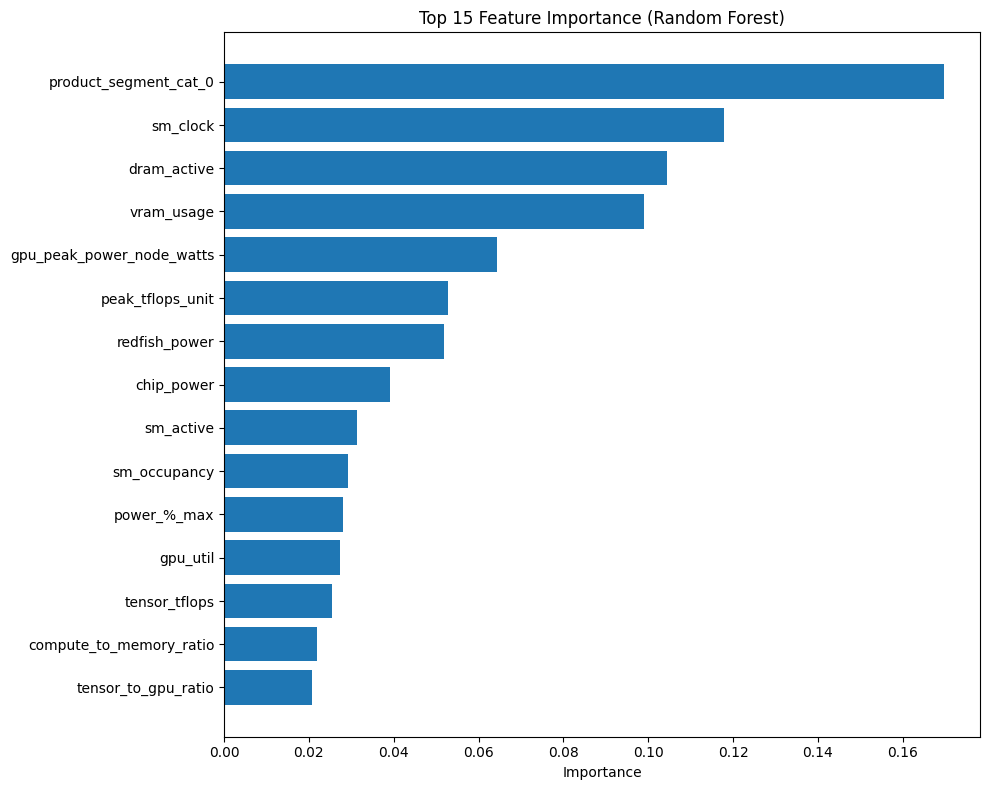


[2/4] PCA Visualization


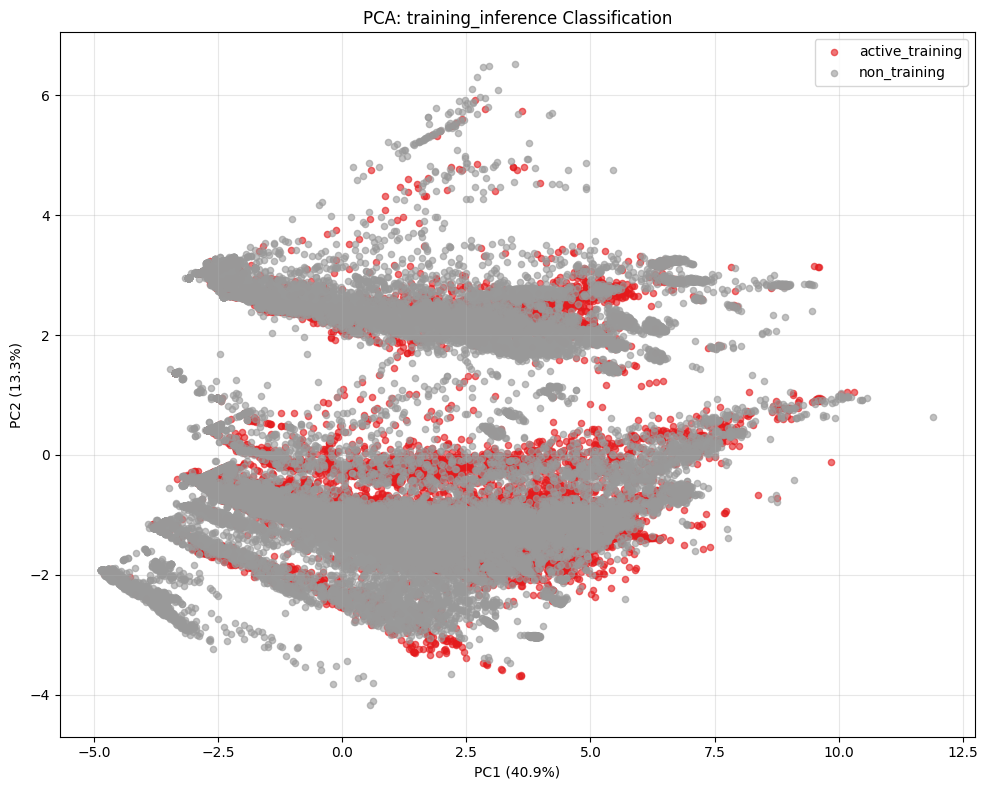


[3/4] Confusion Matrix


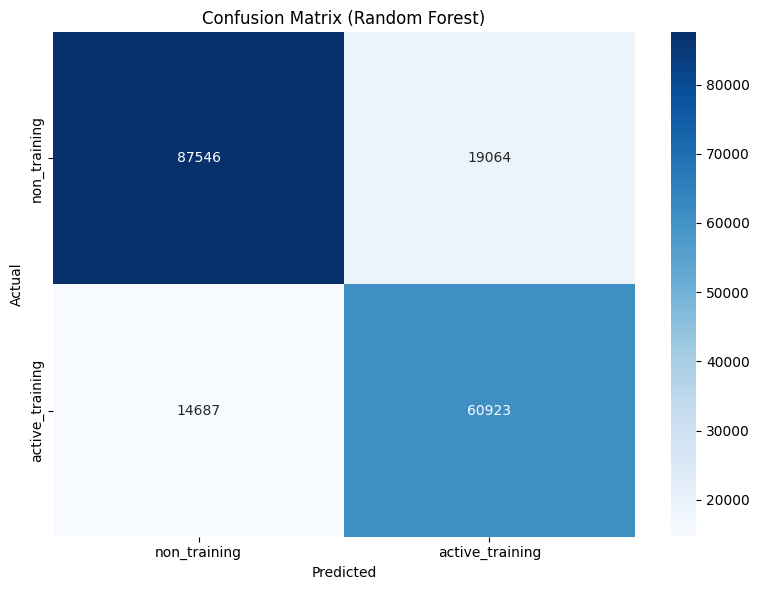


[4/4] Model Comparison


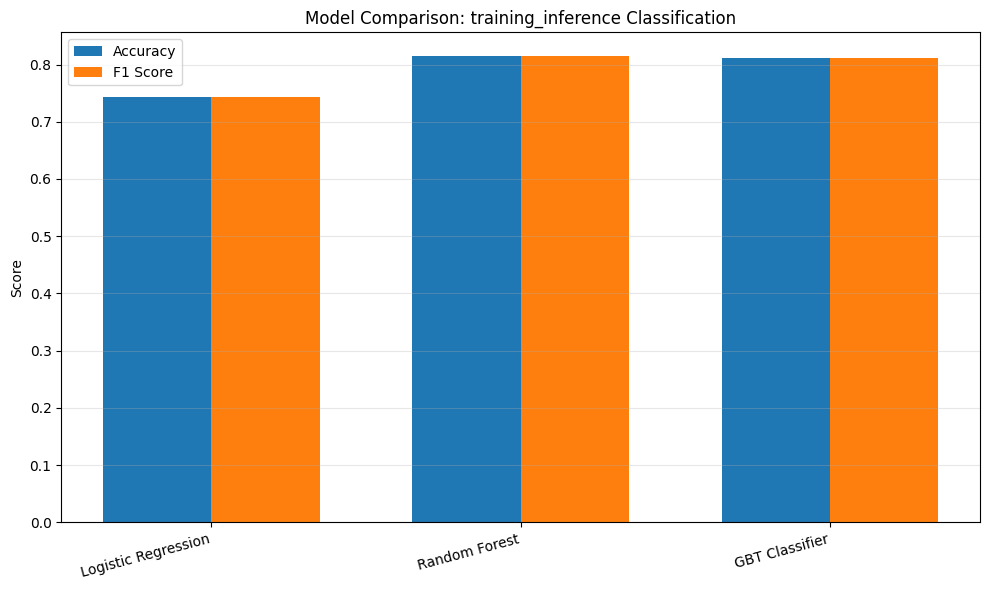


CLASSIFICATION REPORT
                 precision    recall  f1-score   support

   non_training     0.8563    0.8212    0.8384    106610
active_training     0.7617    0.8058    0.7831     75610

       accuracy                         0.8148    182220
      macro avg     0.8090    0.8135    0.8107    182220
   weighted avg     0.8171    0.8148    0.8154    182220


CLASSIFICATION ANALYSIS COMPLETE

Best Model: Random Forest
Test Accuracy: 0.8148
Test F1 Score: 0.8154

✓ Memory released


In [25]:
# CLASSIFICATION VISUALIZATION: training_inference# ========================================# Generate visualizations inline in notebookimport osimport numpy as npimport pandas as pdimport matplotlib.pyplot as pltimport seaborn as snsfrom sklearn.decomposition import PCAfrom sklearn.metrics import confusion_matrix, classification_reportprint("="*60)print("CLASSIFICATION VISUALIZATION")print("="*60)# Explain Categorical Feature Encodingprint("\nCategorical Feature Encoding:")print("="*60)print("product_segment categories:")# Get the StringIndexer from encoding_model to see the label mappingfrom pyspark.ml import PipelineModelstages = encoding_model.stages# Find the StringIndexer for product_segmentfor stage in stages:    if hasattr(stage, 'getInputCol') and stage.getInputCol() == 'product_segment':        if hasattr(stage, 'labels'):            labels = stage.labels            print(f"  Total categories: {len(labels)}")            for i, label in enumerate(labels):                print(f"    product_segment_cat_{i} = {label}")            print(f"\n  Note: One-hot encoding creates {len(labels)-1} binary features")            print(f"        (last category is encoded as all zeros)")        breakprint("="*60)# Sample for Dimensionality ReductionSAMPLE_FOR_VIZ = 0.1SEED = 42print(f"\nSampling {SAMPLE_FOR_VIZ*100:.0f}% for dimensionality reduction...")df_sample = df_ml.sample(False, SAMPLE_FOR_VIZ, seed=SEED)sample_pd = df_sample.select("features", "label", TARGET_COL).toPandas()print(f"Sample size: {len(sample_pd):,} rows")# Convert Spark vectors to numpy arraysfrom pyspark.ml.linalg import VectorsX_sample = np.array([np.array(row.features.toArray()) for row in sample_pd.itertuples()])y_sample = sample_pd[TARGET_COL].valuesprint(f"✓ Converted to numpy: {X_sample.shape}")# ========================================# Dimensionality Reduction# ========================================print("\nPerforming dimensionality reduction...")# PCAprint("  Running PCA...")pca = PCA(n_components=2, random_state=SEED)X_pca = pca.fit_transform(X_sample)print(f"    Explained variance: {pca.explained_variance_ratio_.sum():.2%}")# Interpret Principal Componentsprint("\nPrincipal Component Interpretation:")print("="*60)# Build feature names matching the actual feature vector# The feature vector is built from numeric features + one-hot encoded categoricaln_features = len(pca.components_[0])# Start with numeric features that exist in the dataframefeature_names_list = [col for col in numeric_features if col in df_classification.columns]# Add categorical feature names (one-hot encoded creates multiple binary features)for col in categorical_features:    if col in df_classification.columns:        # One-hot encoding creates n-1 features for n categories        num_categories = df_classification.select(col).distinct().count()        for i in range(num_categories - 1):            feature_names_list.append(f"{col}_cat_{i}")# Ensure we have the right number of feature namesif len(feature_names_list) < n_features:    # Pad with generic names    for i in range(len(feature_names_list), n_features):        feature_names_list.append(f"feature_{i}")elif len(feature_names_list) > n_features:    # Truncate    feature_names_list = feature_names_list[:n_features]# Get loadings (components)pc1_loadings = pd.DataFrame({    'feature': feature_names_list,    'loading': pca.components_[0]})pc1_loadings['abs_loading'] = pc1_loadings['loading'].abs()pc1_loadings = pc1_loadings.sort_values('abs_loading', ascending=False)pc2_loadings = pd.DataFrame({    'feature': feature_names_list,    'loading': pca.components_[1]})pc2_loadings['abs_loading'] = pc2_loadings['loading'].abs()pc2_loadings = pc2_loadings.sort_values('abs_loading', ascending=False)print(f"\nPC1 (explains {pca.explained_variance_ratio_[0]:.1%} of variance):")print("Top 5 contributing features:")for idx, row in pc1_loadings.head(5).iterrows():    print(f"  {row['feature']:30s} {row['loading']:7.4f}")print(f"\nPC2 (explains {pca.explained_variance_ratio_[1]:.1%} of variance):")print("Top 5 contributing features:")for idx, row in pc2_loadings.head(5).iterrows():    print(f"  {row['feature']:30s} {row['loading']:7.4f}")print(f"\nInterpretation:")print(f"- PC1 captures the direction of maximum variance in the feature space")print(f"- PC2 captures the second-most important direction (orthogonal to PC1)")print(f"- Together they explain {pca.explained_variance_ratio_.sum():.1%} of total variance")print(f"\nUnderstanding Loadings:")print(f"- MAGNITUDE (absolute value): How much the feature contributes to that PC")print(f"- SIGN (+/-): The direction of the relationship")print(f"  * Positive loading: Feature increases as you move in the positive PC direction")print(f"  * Negative loading: Feature decreases as you move in the positive PC direction")print(f"  * Features with opposite signs are negatively correlated along that PC")print(f"\nExample from PC2 above:")print(f"- product_segment_cat_1 (+0.53) and product_segment_cat_0 (-0.35) have opposite signs")print(f"- This means PC2 separates these product segments: high PC2 → more cat_1, low PC2 → more cat_0")print(f"- PC2 is essentially a 'product segment differentiation' axis")print("="*60)# ========================================# Generate Visualizations# ========================================print("\nGenerating visualizations...\n")# 1. Feature Importance Plotprint("[1/4] Feature Importance")fig, ax = plt.subplots(figsize=(10, 8))top_15 = importance_df.head(15)ax.barh(range(len(top_15)), top_15["importance"].values)ax.set_yticks(range(len(top_15)))ax.set_yticklabels(top_15["feature"].values)ax.set_xlabel("Importance")ax.set_title(f"Top 15 Feature Importance ({best_model_name})")ax.invert_yaxis()plt.tight_layout()plt.show()# 2. PCA Scatter Plotprint("\n[2/4] PCA Visualization")fig, ax = plt.subplots(figsize=(10, 8))# Create color map for classesunique_classes = np.unique(y_sample)colors = plt.cm.Set1(np.linspace(0, 1, len(unique_classes)))color_map = dict(zip(unique_classes, colors))for cls in unique_classes:    mask = y_sample == cls    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],               c=[color_map[cls]],               label=cls,               alpha=0.6,               s=20)ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")ax.set_title("PCA: training_inference Classification")ax.legend()ax.grid(True, alpha=0.3)plt.tight_layout()plt.show()# 3. Confusion Matrixprint("\n[3/4] Confusion Matrix")pred_pd = rf_pred.select("label", "prediction", TARGET_COL).toPandas()# Get label mappinglabel_to_name = pred_pd.groupby("label")[TARGET_COL].first().to_dict()sorted_labels = sorted(label_to_name.keys())label_names = [label_to_name[i] for i in sorted_labels]cm = confusion_matrix(pred_pd["label"], pred_pd["prediction"], labels=sorted_labels)fig, ax = plt.subplots(figsize=(8, 6))sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",             xticklabels=label_names, yticklabels=label_names, ax=ax)ax.set_xlabel("Predicted")ax.set_ylabel("Actual")ax.set_title(f"Confusion Matrix ({best_model_name})")plt.tight_layout()plt.show()# 4. Model Comparison Bar Chartprint("\n[4/4] Model Comparison")fig, ax = plt.subplots(figsize=(10, 6))x_pos = np.arange(len(results_df))width = 0.35ax.bar(x_pos - width/2, results_df["Accuracy"], width, label="Accuracy")ax.bar(x_pos + width/2, results_df["F1 Score"], width, label="F1 Score")ax.set_ylabel("Score")ax.set_title("Model Comparison: training_inference Classification")ax.set_xticks(x_pos)ax.set_xticklabels(results_df["Model"], rotation=15, ha="right")ax.legend()ax.grid(axis="y", alpha=0.3)plt.tight_layout()plt.show()# Classification Reportprint("\n" + "="*60)print("CLASSIFICATION REPORT")print("="*60)print(classification_report(pred_pd["label"], pred_pd["prediction"],                           target_names=label_names, digits=4))print("\n" + "="*60)print("CLASSIFICATION ANALYSIS COMPLETE")print("="*60)print(f"\nBest Model: {best_model_name}")print(f"Test Accuracy: {results_df.loc[results_df['Model'] == best_model_name, 'Accuracy'].values[0]:.4f}")print(f"Test F1 Score: {results_df.loc[results_df['Model'] == best_model_name, 'F1 Score'].values[0]:.4f}")# Clean uptrain_df.unpersist()test_df.unpersist()df_ml.unpersist()print("\n✓ Memory released")

In [ ]:
df_check = ness.sql("select * from sandbox.sandbox_finance.dcgm_metrics_raw_impute limit 10")
df_check.show(5,truncate=False)